# Import

In [53]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

# Load preprocessed dataset

In [54]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

train_df = pd.read_csv(DATA_DIR / "train_processed.csv")
test_df = pd.read_csv(DATA_DIR / "test_processed.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
# train_df.head(20)
positive = train_df[train_df["label"] == 1].head(2)
negative = train_df[train_df["label"] == 0].head(2)

display(pd.concat([positive, negative]))

Training shape: (24904, 2)
Testing shape: (24801, 2)


,processed_text,label
0,bromwell high cartoon comedy ran time program ...,1
1,homelessness houselessness george carlin state...,1
12472,story man unnatural feeling pig start opening ...,0
12473,airport 77 start brand new luxury 747 plane lo...,0


# Configure device

In [55]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Using device: cuda
GPU: NVIDIA GeForce MX570 A


# Train validation test split

In [56]:
from sklearn.model_selection import train_test_split
train_data, val_data=train_test_split(train_df,test_size=0.2,random_state=SEED,stratify=train_df["label"])  
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Testing samples:", len(test_df))

print("\nTraining labels:")
print(train_data["label"].value_counts())

print("\nValidation labels:")
print(val_data["label"].value_counts())

Training samples: 19923
Validation samples: 4981
Testing samples: 24801

Training labels:
label
1    9977
0    9946
Name: count, dtype: int64

Validation labels:
label
1    2495
0    2486
Name: count, dtype: int64


# Vocabulary construction

In [57]:
from collections import Counter

In [58]:
# build the vocabulary using only the training set
train_tokens=train_data["processed_text"].str.split()
word_counts=Counter()
for tokens in train_tokens:
    word_counts.update(tokens)
word_counts

Counter({'not': 47596,
         'movie': 41504,
         'film': 37415,
         'one': 22135,
         'like': 16561,
         'time': 12688,
         'would': 12366,
         'good': 12291,
         'character': 11309,
         'story': 10435,
         'no': 10051,
         'even': 10044,
         'get': 10033,
         'make': 9712,
         'see': 9514,
         'really': 9400,
         'well': 8592,
         'scene': 8434,
         'much': 7863,
         'people': 7547,
         'could': 7522,
         'bad': 7443,
         'also': 7373,
         'great': 7292,
         'first': 7216,
         'way': 7051,
         'show': 6903,
         'made': 6666,
         'thing': 6558,
         'life': 6537,
         'think': 6208,
         'go': 6104,
         'know': 5711,
         'watch': 5702,
         'plot': 5513,
         'year': 5499,
         'love': 5492,
         'actor': 5476,
         'two': 5465,
         'seen': 5391,
         'many': 5309,
         'end': 5301,
         'loo

In [59]:
# create the vocabulary
word_to_idx={
    "<PAD>":0,
    "<UNK>":1
}
for word, _ in word_counts.items():
    word_to_idx[word]=len(word_to_idx)
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

In [60]:
# check
print(f"Vocabulary size: {len(word_to_idx):,}")

print("\nFirst 10 words:")
for word, idx in list(word_to_idx.items())[:10]:
    print(f"{word}: {idx}")

Vocabulary size: 60,725

First 10 words:
<PAD>: 0
<UNK>: 1
saddens: 2
rate: 3
movie: 4
lot: 5
favorite: 6
actor: 7
location: 8
genre: 9


# Integer Encoding

## encoding function

In [61]:
def encode_review(tokens, vocabulary):
    encoded_review = []

    for word in tokens:
        if word in vocabulary:
            encoded_review.append(vocabulary[word])
        else:
            encoded_review.append(vocabulary["<UNK>"])

    return encoded_review

In [62]:
print(word_to_idx["<UNK>"])

1


## convert string into list of tokens

In [63]:
train_tokens = train_data["processed_text"].str.split()
val_tokens = val_data["processed_text"].str.split()
test_tokens = test_df["processed_text"].str.split()

## encode

In [64]:
train_sequences = train_tokens.apply(
    lambda review: encode_review(review, word_to_idx)
)

val_sequences = val_tokens.apply(
    lambda review: encode_review(review, word_to_idx)
)

test_sequences = test_tokens.apply(
    lambda review: encode_review(review, word_to_idx)
)

In [65]:
print("Original review:")
print(train_tokens.iloc[0])

print("\nEncoded review:")
print(train_sequences.iloc[0])

Original review:
['saddens', 'rate', 'movie', 'lot', 'favorite', 'actor', 'location', 'genre', 'e', 'douglas', 'sutherland', 'washington', 'c', 'political', 'thriller', 'sentinel', 'really', 'hit', 'low', 'like', 'great', 'idea', 'front', 'signed', 'right', 'cast', 'great', 'city', 'shot', 'took', 'holiday', 'letting', 'remaining', 'crew', 'improvise', 'rest', 'wish', 'could', 'blame', 'yet', 'another', 'bland', 'performance', 'basinger', 'not', 'feel', 'one', 'worst', 'actor', 'hollywood', 'still', 'steaming', 'decade', 'later', 'one', 'definitely', 'bad', 'actor', 'film', 'win', 'acting', 'oscar', 'l', 'confidential', 'not', 'problem', 'sutherland', 'love', 'jack', 'bauer', '24', 'play', 'jack', 'miss', 'old', 'time', 'kill', 'good', 'men', 'day', 'douglas', 'certainly', 'took', 'hiatus', 'acting', 'phoned', 'one', 'plot', 'someone', 'secret', 'service', 'traitor', 'want', 'president', 'dead', 'douglas', 'haphazardly', 'framed', 'someone', 'believe', 'actually', 'no', 'spoiler', 'qui

# Sequence padding

## sequence length analysis

In [66]:
sequence_lengths = train_sequences.apply(len)
print(sequence_lengths.describe())

count    19923.000000
mean       124.483913
std         93.641799
min          6.000000
25%         66.000000
50%         93.000000
75%        151.000000
max       1449.000000
Name: processed_text, dtype: float64


In [67]:
print(f"90th percentile: {int(sequence_lengths.quantile(0.90))}")
print(f"95th percentile: {int(sequence_lengths.quantile(0.95))}")
print(f"99th percentile: {int(sequence_lengths.quantile(0.99))}")
print(f"Maximum length: {sequence_lengths.max()}")

90th percentile: 247
95th percentile: 321
99th percentile: 479
Maximum length: 1449


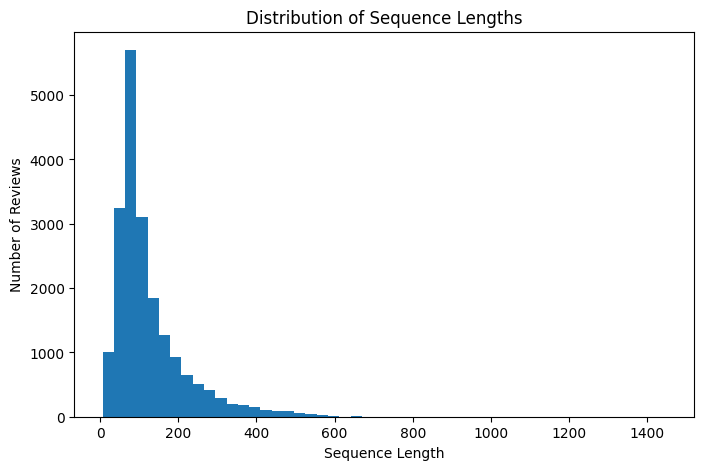

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(sequence_lengths, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Sequence Lengths")
plt.show()

The maximum sequence length was set to 321 tokens, corresponding to the 95th percentile of the training review lengths. This preserves approximately 95% of the reviews without truncation while keeping the computational cost manageable

## padding

In [69]:
MAX_LENGTH = 321
PAD_ID = word_to_idx["<PAD>"]

def pad_or_truncate(sequence, max_length, pad_id):
    if len(sequence) >= max_length:
        return sequence[:max_length]

    return sequence + [pad_id] * (max_length - len(sequence))

In [70]:
train_padded = np.array([
    pad_or_truncate(sequence, MAX_LENGTH, PAD_ID)
    for sequence in train_sequences
])

val_padded = np.array([
    pad_or_truncate(sequence, MAX_LENGTH, PAD_ID)
    for sequence in val_sequences
])

test_padded = np.array([
    pad_or_truncate(sequence, MAX_LENGTH, PAD_ID)
    for sequence in test_sequences
])

In [71]:
print("Training shape:", train_padded.shape)
print("Validation shape:", val_padded.shape)
print("Testing shape:", test_padded.shape)

print("First sequence length:", len(train_padded[0]))

Training shape: (19923, 321)
Validation shape: (4981, 321)
Testing shape: (24801, 321)
First sequence length: 321


# Prepare labels and seq lengths

In [72]:
train_lengths = np.array([
    min(len(sequence), MAX_LENGTH)
    for sequence in train_sequences
])

val_lengths = np.array([
    min(len(sequence), MAX_LENGTH)
    for sequence in val_sequences
])

test_lengths = np.array([
    min(len(sequence), MAX_LENGTH)
    for sequence in test_sequences
])

y_train = train_data["label"].to_numpy(dtype=np.float32)
y_val = val_data["label"].to_numpy(dtype=np.float32)
y_test = test_df["label"].to_numpy(dtype=np.float32)

print("Training sequences:", train_padded.shape)
print("Training lengths:", train_lengths.shape)
print("Training labels:", y_train.shape)

Training sequences: (19923, 321)
Training lengths: (19923,)
Training labels: (19923,)


# Save Shared Data

In [73]:
SHARED_DIR = DATA_DIR / "shared"
SHARED_DIR.mkdir(parents=True, exist_ok=True)

In [74]:
import pickle

with open(SHARED_DIR / "vocabulary.pkl", "wb") as file:
    pickle.dump(
        {
            "word_to_idx": word_to_idx,
            "MAX_LENGTH": MAX_LENGTH
        },
        file
    )

print("Shared vocabulary saved successfully.")

Shared vocabulary saved successfully.


In [75]:
np.savez_compressed(
    SHARED_DIR / "sequence_data.npz",

    train_padded=train_padded,
    val_padded=val_padded,
    test_padded=test_padded,

    train_lengths=train_lengths,
    val_lengths=val_lengths,
    test_lengths=test_lengths,

    y_train=y_train,
    y_val=y_val,
    y_test=y_test,

    train_texts=train_data["processed_text"].to_numpy(),
    val_texts=val_data["processed_text"].to_numpy(),
    test_texts=test_df["processed_text"].to_numpy()
)

print("Shared sequence data saved successfully.")

Shared sequence data saved successfully.
